# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**
*Edición 2023*

----

## **Introducción al Aprendizaje Automático**
## **Laboratorio 2: Armado de un esquema de aprendizaje automático**

**GRUPO 11**
- Mendoza, Ruben Alfredo
- Risso, Sofia Agostina

En el laboratorio final se espera que puedan poner en práctica los conocimientos adquiridos en el curso, trabajando con un conjunto de datos de clasificación.

El objetivo es que se introduzcan en el desarrollo de un esquema para hacer tareas de aprendizaje automático: selección de un modelo, ajuste de hiperparámetros y evaluación.

El conjunto de datos a utilizar está en `./data/loan_data.csv`. Si abren el archivo verán que al principio (las líneas que empiezan con `#`) describen el conjunto de datos y sus atributos (incluyendo el atributo de etiqueta o clase).

Se espera que hagan uso de las herramientas vistas en el curso. Se espera que hagan uso especialmente de las herramientas brindadas por `scikit-learn`.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.fixes import loguniform
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

### Planteo de la Situacion Problematica.

El departamento de crédito al consumidor de un banco desea automatizar el proceso de toma de decisiones para la aprobación de líneas de crédito con garantía hipotecaria. Para lograr esto, seguirán las recomendaciones de la Ley de Igualdad de Oportunidades de Crédito para crear un modelo de puntuación crediticia empíricamente derivado y estadísticamente sólido. El modelo se basará en datos recopilados de solicitantes recientes que hayan obtenido crédito a través del proceso actual de evaluación de préstamos. El modelo se construirá utilizando herramientas de modelado predictivo, pero debe ser suficientemente interpretable para proporcionar una razón en caso de acciones adversas (rechazos).


## Carga de datos y división en entrenamiento y evaluación

La celda siguiente se encarga de la carga de datos (haciendo uso de pandas). Estos serán los que se trabajarán en el resto del laboratorio.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

In [8]:
dataset = pd.read_csv("loan_data.csv", comment="#")
dataset

,TARGET,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,0,4700,88026.0,115506.0,6.0,0.0,0.0,182.248332,0.0,27.0,29.209023
1,0,19300,39926.0,101208.0,4.0,0.0,0.0,140.051638,0.0,14.0,31.545694
2,0,5700,71556.0,79538.0,2.0,0.0,0.0,92.643085,0.0,15.0,41.210012
3,0,13000,44875.0,57713.0,0.0,1.0,0.0,184.990324,1.0,12.0,28.602076
4,0,19300,72752.0,106084.0,11.0,0.0,0.0,193.707100,1.0,13.0,30.686106
...,...,...,...,...,...,...,...,...,...,...,...
1849,1,53400,228236.0,305514.0,6.0,0.0,0.0,11.148069,0.0,2.0,34.558417
1850,1,53600,235895.0,299772.0,5.0,0.0,0.0,112.748282,7.0,22.0,44.945929
1851,1,53600,208197.0,297280.0,4.0,1.0,1.0,160.485251,2.0,29.0,41.646731
1852,1,65500,205156.0,290239.0,2.0,0.0,0.0,98.808206,1.0,21.0,144.189001


In [9]:
dataset.isna().sum()

TARGET     0
LOAN       0
MORTDUE    0
VALUE      0
YOJ        0
DEROG      0
DELINQ     0
CLAGE      0
NINQ       0
CLNO       0
DEBTINC    0
dtype: int64

In [10]:
dataset.describe().style.format('{:.2f}')

,TARGET,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,1854.00,1854.00,1854.00,1854.00,1854.00,1854.00,1854.00,1854.00,1854.00,1854.00,1854.00
mean,0.17,19111.76,76316.05,107321.09,8.90,0.19,0.32,180.30,1.13,21.86,34.57
std,0.37,11000.35,46227.03,56039.69,7.55,0.70,0.93,84.84,1.66,9.51,9.31
min,0.00,1700.00,5627.00,21144.00,0.00,0.00,0.00,0.49,0.00,0.00,0.84
25%,0.00,12000.00,48984.75,70787.25,3.00,0.00,0.00,116.97,0.00,16.00,29.43
50%,0.00,17000.00,67201.00,94198.00,7.00,0.00,0.00,174.97,1.00,21.00,35.36
75%,0.00,23900.00,93731.50,122976.25,13.00,0.00,0.00,232.26,2.00,27.00,39.36
max,1.00,89800.00,399412.00,512650.00,41.00,10.00,10.00,1168.23,13.00,65.00,144.19


Se realizó una visualización de las distribuciones de cada columna del dataset.

In [11]:
def plot_distribution(dataframe, column_name):

    column_data = dataframe[column_name]

    plt.figure(figsize=(10,4))
    plt.hist(column_data, bins='auto', alpha=0.7, rwidth=0.85)
    plt.grid(axis='y', alpha=0.75)
    plt.xlabel(column_name)
    plt.ylabel('Frecuencia')
    plt.title('Distribución de {}'.format(column_name))

    plt.show()

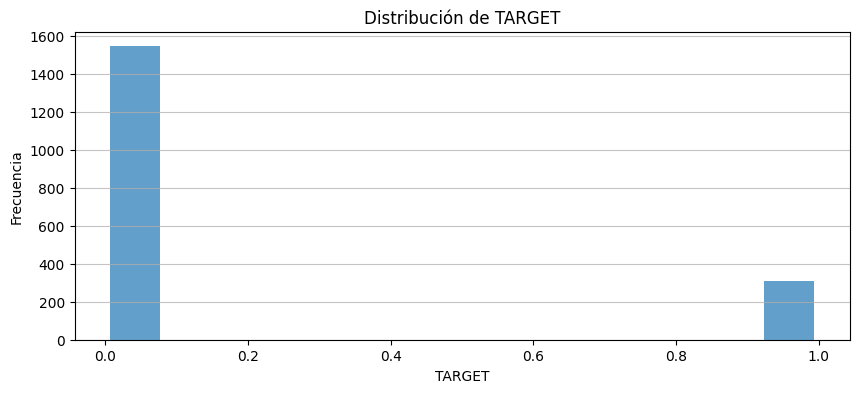

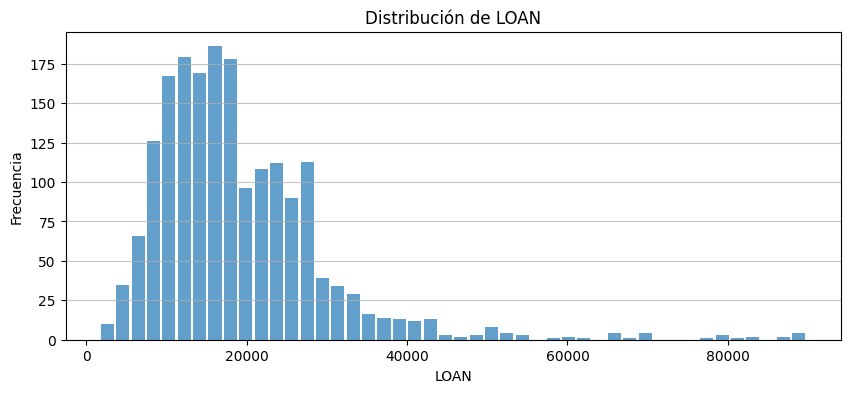

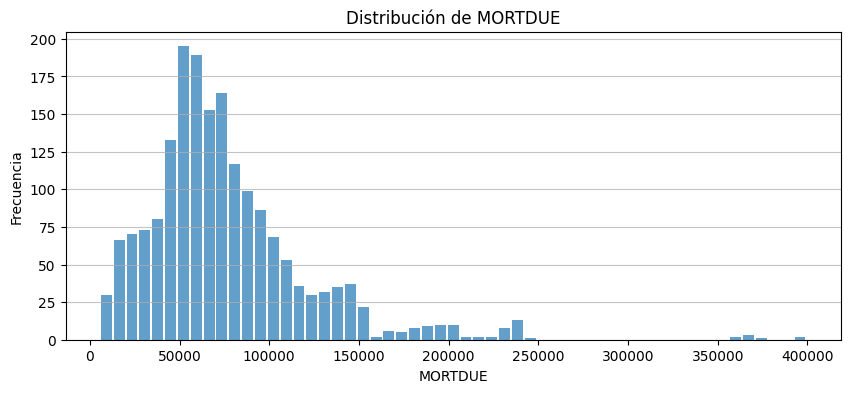

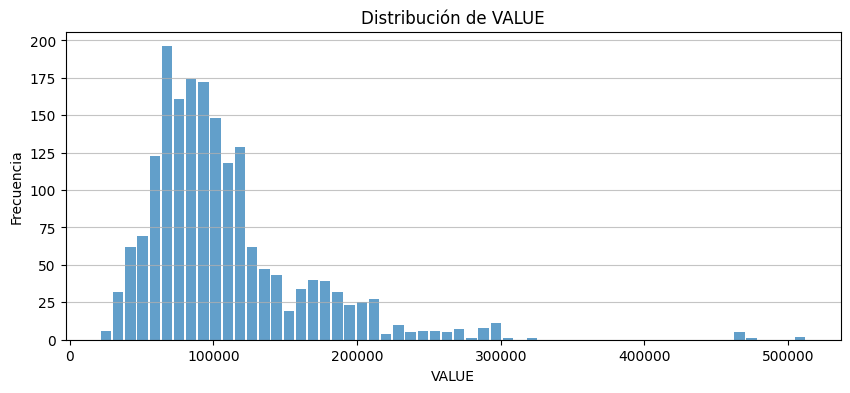

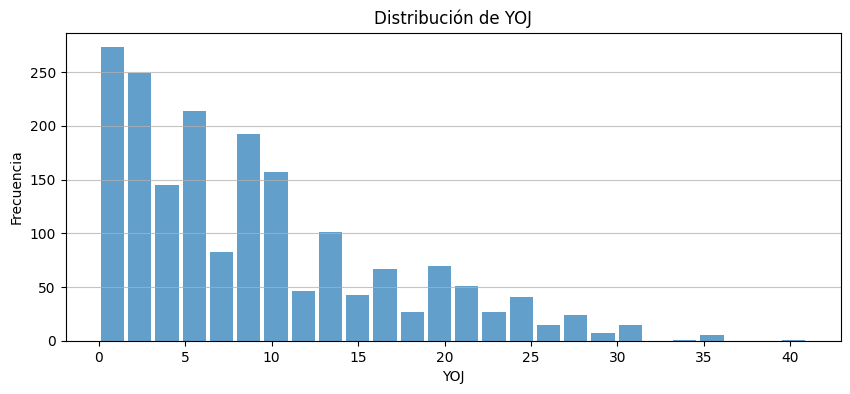

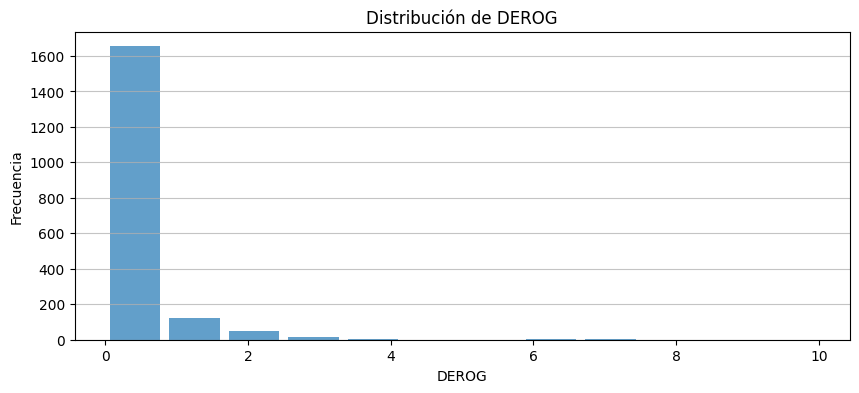

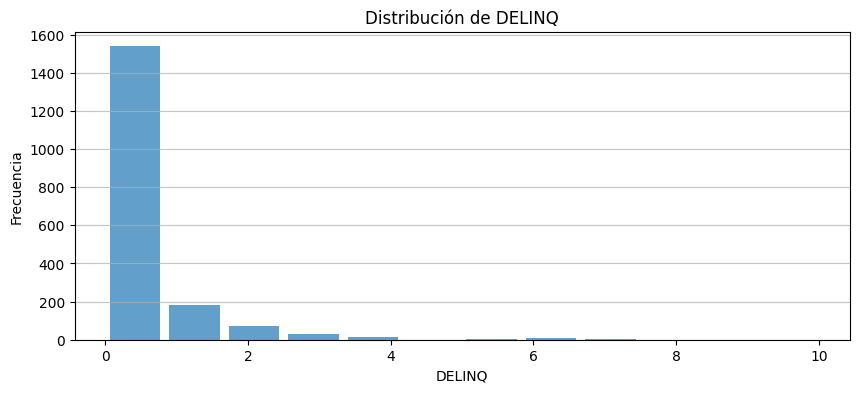

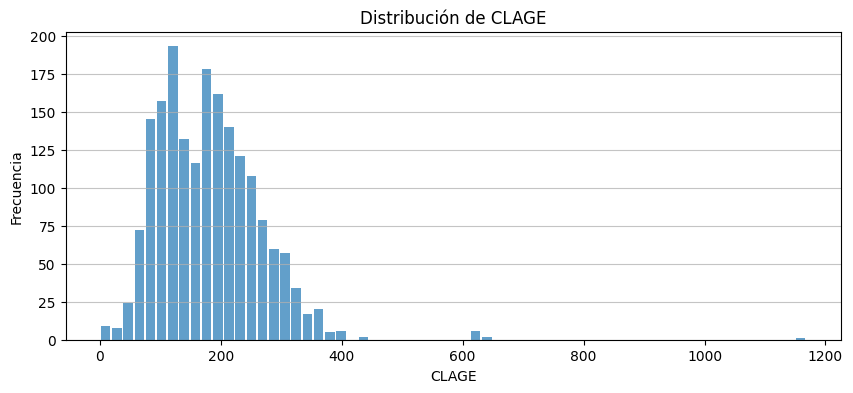

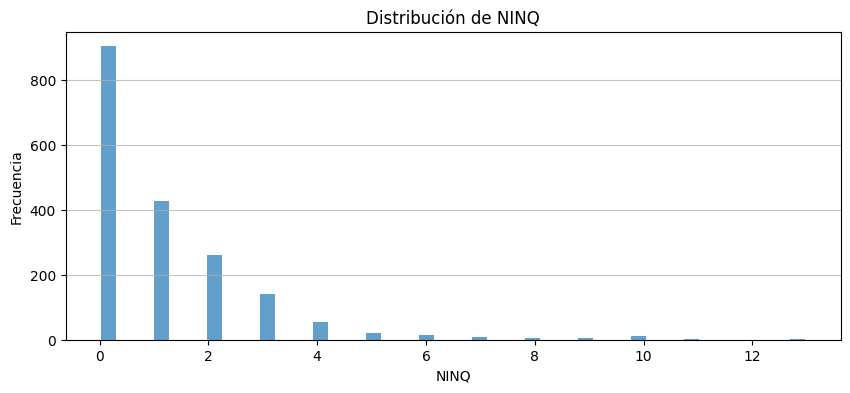

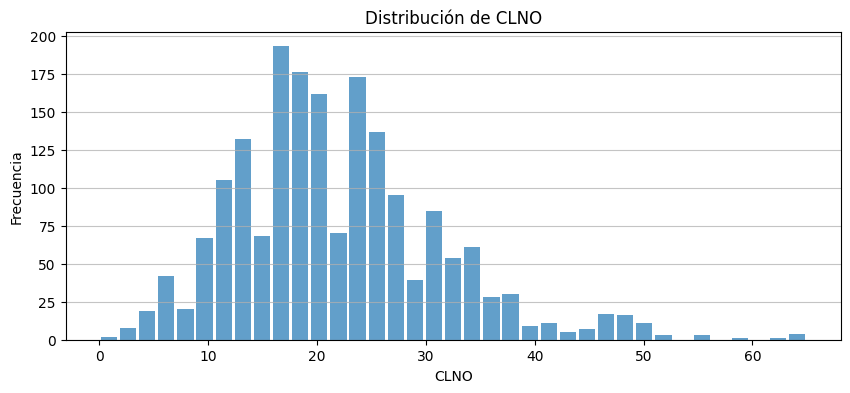

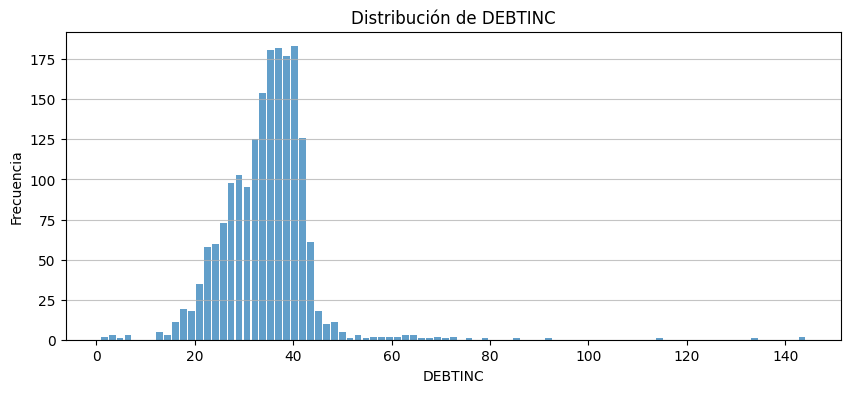

In [12]:
for name in dataset.columns:
    plot_distribution(dataset,name)

El conjunto de datos de Equity de Vivienda (HMEQ) contiene información básica y de rendimiento de préstamos para 5,960 préstamos recientes de equity de vivienda. El objetivo (BAD) es una variable binaria que indica si un solicitante finalmente incurrió en incumplimiento o estuvo seriamente moroso. Este resultado adverso ocurrió en 1,189 casos (20%). Para cada solicitante, se registraron 12 variables de entrada.


Atributos:

1) `TARGET` Representa nuestra variable predictoria:

* `"1"` cliente en incumplimiento del préstamo
* `"0"` préstamo pagado

2) `LOAN` Monto del préstamo solicitado.

3) `MORTDUE` Monto adeudado en la hipoteca existente.

4) `VALUE` Valor de la propiedad actual.

5) `YOJ` Años en el trabajo actual.

6) `DEROG` Número de informes negativos importantes.

7) `DELINQ` Número de líneas de crédito morosas.

8) `CLAGE` Antigüedad de la línea comercial más antigua en meses.

9) `NINQ` Número de líneas de crédito recientes.

10) `CLNO` Número de líneas de crédito.

11) `DEBTINC` Relación deuda-ingresos.

Dado que se quieren entrenar modelos de clasificación, es fundamental verificar que el conjunto de datos utilizado para el entrenamiento esté balanceado, es decir, que haya una distribución equitativa de las clases o categorías en el conjunto de datos. Esto proporciona una representación adecuada de todas las clases, permitiendo que el modelo aprenda de manera efectiva y brinde resultados más precisos en la clasificación de nuevas instancias.

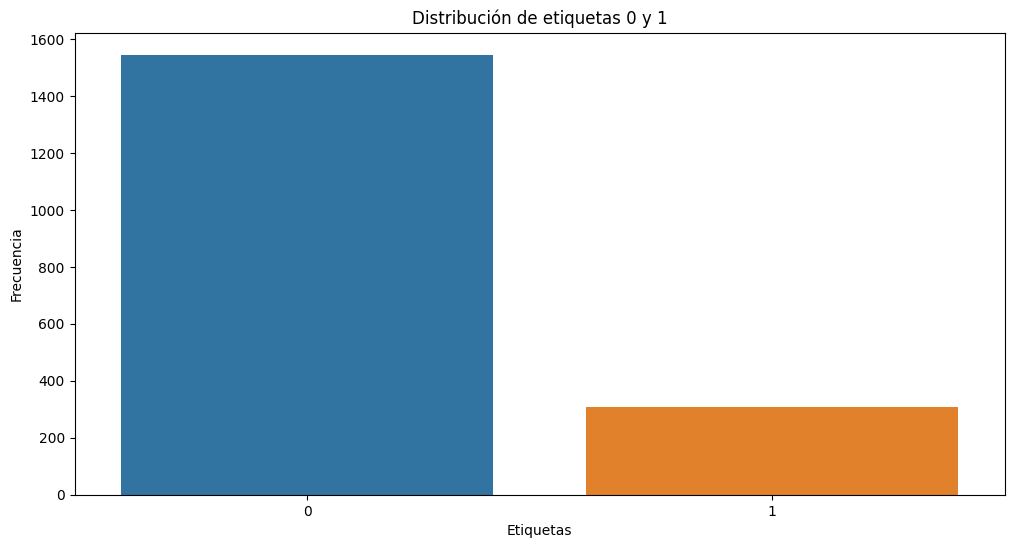

In [14]:
target_counts = dataset['TARGET'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=target_counts.index, y=target_counts.values)

plt.xlabel('Etiquetas')
plt.ylabel('Frecuencia')
plt.title('Distribución de etiquetas 0 y 1')

plt.show()

Al realizar un conteo de etiquetas del conjunto de datos, se observó que existe una notable desigualdad en la distribución de las mismas. Esta disparidad en el número de instancias de cada clase puede tener un impacto significativo en el rendimiento del modelo y la capacidad de generalización.

Para solucionar este problema y asegurar de que el conjunto de entrenamiento sea representativo y equilibrado, se usa la función `stratify` proporcionada por la biblioteca [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) al dividir los datos en conjuntos de entrenamiento y prueba.


La función `stratify` permite realizar una división estratificada del conjunto de datos, preservando la proporción relativa de las clases en ambos conjuntos resultantes. Al utilizar esta función, se asegura que el conjunto de entrenamiento y el conjunto de prueba tengan una distribución similar de etiquetas, reflejando así la distribución real del conjunto de datos completo.

In [15]:
# División entre instancias y etiquetas
X, y = dataset.iloc[:, 1:], dataset.TARGET

# división entre entrenamiento y evaluación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

## Ejercicio 1: Descripción de los Datos y la Tarea

Responder las siguientes preguntas:

**1. ¿De qué se trata el conjunto de datos?**

El conjunto de datos proviene de Equity de Vivienda (HMEQ) y contiene información sobre el rendimiento de préstamos en base a 5960 créditos que habrían sido otorgados recientemente.


**2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?**

La variable objetivo o "TARGET" consiste en entrenar un modelo para que, a partir de los atributos disponibles, clasifique a un cliente como posible incumplidor o no:
* `"1"` cliente en incumplimiento del préstamo
* `"0"` préstamo pagado

**3. ¿Qué información (atributos) hay disponible para hacer la predicción?**
 Para realizar dicha prediccón se disponen de los siguientes atributos:

`LOAN` Monto del préstamo solicitado.

`MORTDUE` Monto adeudado en la hipoteca existente.

`VALUE` Valor de la propiedad actual.

`YOJ` Años en el trabajo actual.

`DEROG` Número de informes negativos importantes.

`DELINQ` Número de líneas de crédito morosas.

`CLAGE` Antigüedad de la línea comercial más antigua en meses.

`NINQ` Número de líneas de crédito recientes.

`CLNO` Número de líneas de crédito.

`DEBTINC` Relación deuda-ingresos.


**4. ¿Qué atributos imagina ud. que son los más determinantes para la predicción?**

Los atributos que se consideran más determinantes para la predicción serían:

`LOAN`, `DEROG` y `DEBTINC`.

## Ejercicio 2: Predicción con Modelos Lineales

En este ejercicio se entrenarán modelos lineales de clasificación para predecir la variable objetivo.

Para ello, deberán utilizar la clase SGDClassifier de scikit-learn.

Documentación:
- https://scikit-learn.org/stable/modules/sgd.html
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html


### Ejercicio 2.1: SGDClassifier con hiperparámetros por defecto

Entrenar y evaluar el clasificador SGDClassifier usando los valores por omisión de scikit-learn para todos los parámetros. Únicamente **fijar la semilla aleatoria** para hacer repetible el experimento.

Evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión

Se creó una instancia del modelo de Clasificador "SGD".

In [16]:
sgdc_model = SGDClassifier(random_state=0)

Se creó y se entrenó un modelo que estandariza todos los datos de entrenamiento ya que estos se encuentran en rangos distintos. Esto se hizo para asegurar que los atributos se consideren en igualdad de condiciones y evitar problemas relacionados con la escala y la magnitud. Al estandarizar los datos, se mejora el rendimiento del modelo, se facilita la optimización y se garantiza una interpretación precisa de los atributos.

Luego se transformaron los datos de prueba de entrada para darle al modelo y que los resultados de la clasificación  fueran comparables.

In [17]:
# Estandarizar los datos de entrenamiento y prueba
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Estandarizados los datos, se procedió a entrenar el modelo.

In [18]:
sgdc_model.fit(X_train, y_train)

SGDClassifier(random_state=0)

Se realizaron las predicciones en los conjuntos de entrenamiento y evaluación.

In [19]:
# Realizar predicciones en el conjunto de entrenamiento y evaluación
y1_train_pred = sgdc_model.predict(X_train)
y1_test_pred = sgdc_model.predict(X_test)

Se evaluó el modelo analizando las métricas calculadas sobre los datos de entrenamiento y los datos de prueba. Primero se calcularon todas las métricas sobre los datos de entrenamiento.

In [20]:
#Evaluamos el modelo en el conjunto de entrenamiento.
train_accu_sgdc = accuracy_score(y_train, y1_train_pred)
train_prec_sgdc = precision_score(y_train, y1_train_pred)
train_recal_sgdc = recall_score(y_train, y1_train_pred)
train_f1_sgdc = f1_score(y_train, y1_train_pred)
train_conf_matrix_sgdc = confusion_matrix(y_train, y1_train_pred)

In [21]:
# Imprimir los resultados de las metricas del conjunto de entrenamiento
print("Resultados en el conjunto de entrenamiento:")
print("Accuracy:", train_accu_sgdc)
print("Precision:", train_prec_sgdc)
print("Recall:", train_recal_sgdc)
print("F1:", train_f1_sgdc)

Resultados en el conjunto de entrenamiento:
Accuracy: 0.8509777478084963
Precision: 0.63
Recall: 0.2550607287449393
F1: 0.3631123919308358


**Accuracy** es una medida que indica la proporción de muestras clasificadas correctamente sobre el total de muestras. Expresa la precisión en general del modelo. En el conjunto de entrenamiento, se obtuvo un valor de 0.8509. Esto indica que el modelo clasifica correctamente cerca del 85% de las muestras en el conjunto de entrenamiento.

**Precision** es una medida que indica la proporción de muestras positivas correctamente clasificadas sobre el total de muestras clasificadas como positivas. Es decir, mide la precisión del clasificador al predecir muestras positivas. En el presente conjunto de entrenamiento, el 'precision' de 0.63 indica que de todas las muestras clasificadas como positivas, el 63% fueron clasificadas correctamente.

**Recall** es una medida que indica la proporción de muestras positivas correctamente clasificadas sobre el total de muestras realmente positivas. Es decir, mide la capacidad del clasificador para encontrar todas las muestras positivas. La diferencia entre **precision** y **recall** es que, **precision** se centra en la precisión de las predicciones positivas, mientras que el recall se centra en la capacidad del modelo para encontrar todas las muestras positivas. La fórmula para calcular la precisión es:

$$Precisión = \frac{Verdaderos\ positivos}{Verdaderos\ positivos + Falsos\ positivos}$$

Mientras que la fórmula para calcular el recall es:

$$Recall = \frac{Verdaderos\ positivos}{Verdaderos\ positivos + Falsos\ negativos}$$

Dicho esto, en el conjunto de entrenamiento, el *recall* de 0.255 indica que el modelo identifica correctamente cerca del 25,5% de todas las muestras positivas en el conjunto de entrenamiento.

El puntaje **F1** es una medida que combina tanto la precisión como el recall en una sola métrica. Representa la media armónica de la precisión y el recall. El F1 score es útil cuando hay un desequilibrio entre las clases en el conjunto de datos. Un valor de F1 score más cercano a 1 indica un mejor equilibrio entre precisión y recall.

Por ultimo, la **matriz de confusión** es una tabla que muestra la distribución de las clasificaciones realizadas por el modelo en función de las clases reales. Proporciona información sobre los verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos. Permite evaluar el desempeño del modelo en cada clase e identificar posibles errores de clasificación.

Para poder visualizarlo se realizó una función que realice un gráfico de la matriz de confusión.

In [22]:
def plot_matriz_conf(matriz_confusion):
    interpretaciones = [['Verdaderos Positivos', 'Falsos Positivos'],
                       ['Falsos Negativos', 'Verdaderos Negativos']]

    fig, ax = plt.subplots()
    im = ax.imshow(matriz_confusion, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    ax.set(title='Matriz de Confusión')

    # Añadir los valores y las interpretaciones en cada celda
    for i in range(matriz_confusion.shape[0]):
        for j in range(matriz_confusion.shape[1]):
            ax.text(j, i, f'{matriz_confusion[i, j]}\n{interpretaciones[i][j]}',
                    ha="center", va="center", color="white" if matriz_confusion[i, j] > (matriz_confusion.max() / 2) else "black")

    plt.xticks([])
    plt.yticks([])

    plt.xlabel('Etiqueta Predicha')
    plt.ylabel('Etiqueta Verdadera')
    plt.tight_layout()
    plt.show()


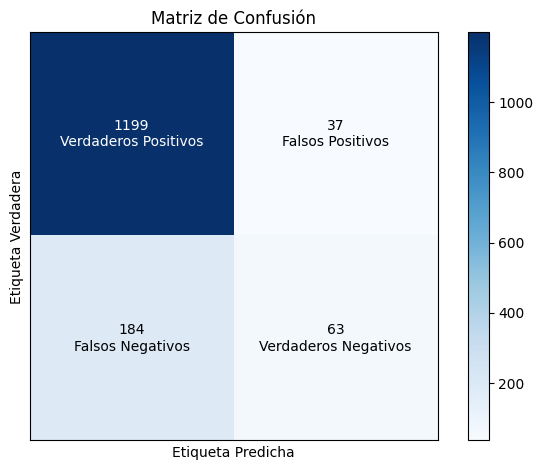

In [23]:
plot_matriz_conf(train_conf_matrix_sgdc)

Luego se analizaron las métricas sobre los datos de prueba.

In [24]:
#Evaluamos el modelo en el conjunto de prueba.
test_accu_sgdc = accuracy_score(y_test, y1_test_pred)
test_prec_sgdc = precision_score(y_test, y1_test_pred)
test_recal_sgdc = recall_score(y_test, y1_test_pred)
test_f1_sgdc = f1_score(y_test, y1_test_pred)
test_conf_matrix_sgdc = confusion_matrix(y_test, y1_test_pred)

In [25]:
# Imprimir los resultados de las metricas del conjunto de prueba
print("\nResultados en el conjunto de evaluación:")
print("Accuracy:", test_accu_sgdc)
print("Precision:", test_prec_sgdc)
print("Recall:", test_recal_sgdc)
print("F1:", test_f1_sgdc)


Resultados en el conjunto de evaluación:
Accuracy: 0.8544474393530997
Precision: 0.6538461538461539
Recall: 0.27419354838709675
F1: 0.38636363636363635


En el conjunto de evaluación se obtuvo un valor de *Accuracy* de 0.8544. Esto indica que el modelo clasifica correctamente aproximadamente del 85% de las muestras, un valor parecido al obtenido en los datos de entrenamiento.

El valor para *Precision* de 0.6538 indica que aproximadamente el 65% de las muestras clasificadas como positivas fueron clasificadas correctamente.

El *recall* de 0.2741 indica que el modelo identifica correctamente cerca del 27% de todas las muestras positivas en el conjunto de evaluación.

Por último, se visualiza cómo es la **matriz de confusión**.

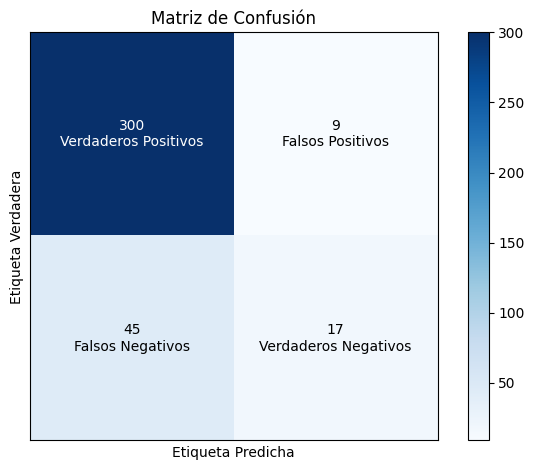

In [26]:
plot_matriz_conf(test_conf_matrix_sgdc)

### Ejercicio 2.2: Ajuste de Hiperparámetros

Seleccionar valores para los hiperparámetros principales del SGDClassifier. Como mínimo, probar diferentes funciones de loss, tasas de entrenamiento y tasas de regularización.

Para ello, usar grid-search y 5-fold cross-validation sobre el conjunto de entrenamiento para explorar muchas combinaciones posibles de valores.

Reportar accuracy promedio y varianza para todas las configuraciones.

Para la mejor configuración encontrada, evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión

Documentación:
- https://scikit-learn.org/stable/modules/grid_search.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

Primero se creó un diccionario donde almacenar los diferentes valores para los hiperparametros que se probarían más adelante.

In [27]:
# Definir los hiperparámetros para GridSearch
params = {
    'loss': ['hinge', 'log_loss', 'modified_huber', 'preceptron'],
    'learning_rate': ['constant', 'optimal', 'invscaling'],
    'alpha': [0.001, 0.01, 0.1]
}

Se creó una instancia nueva del modelo SGDClassifier para probar con diferentes hiperparametros.

In [28]:
sgdc_model_opt = SGDClassifier(random_state=0)

Se realizó una búsqueda en cuadrícula (grid search) con validación cruzada para ajustar y encontrar los mejores hiperparámetros para un modelo de clasificación basado en SGD (Gradiente Descendente Estocástico).


In [29]:
# Realizar la búsqueda en cuadrícula con validación cruzada
grid_search = GridSearchCV(sgdc_model_opt, params, cv=5)
grid_search.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
135 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py", line 892, in fit
    self._more_validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py", line 149, in _more_validate_params
    raise ValueError("eta0 must be > 0"

GridSearchCV(cv=5, estimator=SGDClassifier(random_state=0),
             param_grid={'alpha': [0.001, 0.01, 0.1],
                         'learning_rate': ['constant', 'optimal', 'invscaling'],
                         'loss': ['hinge', 'log_loss', 'modified_huber',
                                  'preceptron']})

Durante la ejecución de `grid_search.fit()` , se realizan varias iteraciones en las que se ajusta el modelo SGDClassifier con diferentes combinaciones de los hiperparámetros especificados en `params`. Cada iteración utiliza un subconjunto diferente de los datos de entrenamiento para entrenar el modelo y luego se evalúa utilizando los datos de validación cruzada.

Al finalizar la búsqueda en cuadrícula, grid_search contiene el modelo ajustado con los mejores hiperparámetros encontrados durante el proceso de búsqueda. Este modelo optimizado se puede utilizar para realizar predicciones en nuevos datos.

In [30]:
# Obtener los resultados
best_sgdc_model = grid_search.best_estimator_
best_sgdc_params = grid_search.best_params_
print("Mejor configuración encontrada:", best_sgdc_params)

Mejor configuración encontrada: {'alpha': 0.01, 'learning_rate': 'optimal', 'loss': 'modified_huber'}


Una vez que se obtuvo el modelo con los mejores hiperparametros y se entrenaron, se hicieron las predicciones sobre los datos de entrenamiento y prueba, para poder evaluar las métricas.

In [31]:
# Realizar predicciones en el conjunto de entrenamiento y evaluación.
y1_train_pred_opt = best_sgdc_model.predict(X_train)
y1_test_pred_opt = best_sgdc_model.predict(X_test)

Como se hizo previamente, primero se evaluaron las métricas sobre los datos de entrenamiento.

In [32]:
#Evaluamos el modelo en el conjunto de entrenamiento.
train_accu_sgdc_opt = accuracy_score(y_train, y1_train_pred_opt)
train_prec_sgdc_opt = precision_score(y_train, y1_train_pred_opt)
train_recal_sgdc_opt = recall_score(y_train, y1_train_pred_opt)
train_f1_sgdc_opt = f1_score(y_train, y1_train_pred_opt)
train_conf_matrix_sgdc_opt = confusion_matrix(y_train, y1_train_pred_opt)

In [33]:
# Imprimir los resultados de las metricas del conjunto de entrenamiento
print("Resultados en el conjunto de entrenamiento:")
print("Accuracy:", train_accu_sgdc_opt)
print("Precision:", train_prec_sgdc_opt)
print("Recall:", train_recal_sgdc_opt)
print("F1:", train_f1_sgdc_opt)

Resultados en el conjunto de entrenamiento:
Accuracy: 0.8698583951449764
Precision: 0.8
Recall: 0.291497975708502
F1: 0.427299703264095


El valor para el *Accuracy* de 0.8698 indica que el modelo clasifica correctamente aproximadamente el 87% de las muestras, un valor mayor que el obtenido por el modelo con hiperparametros por defecto.

El valor para *Precision* de 0.8 indica que el 80% de las muestras clasificadas como positivas fueron clasificadas correctament, resultado más optimo que el modelo anterior.

El *Recall* de 0.2914 indica que el modelo identifica correctamente cerca del 29% de todas las muestras positivas en el conjunto de prueba.

Por último, se realizó la **matriz de confusión**.

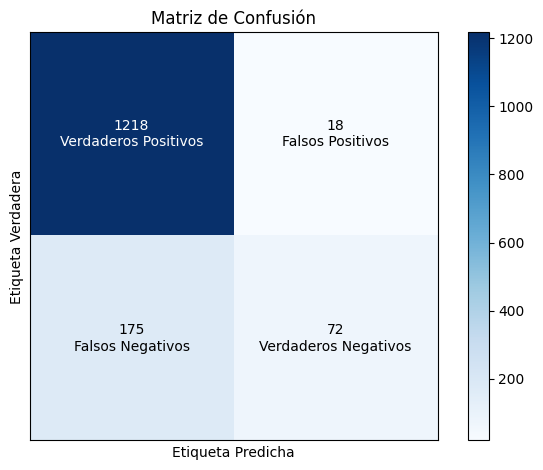

In [34]:
plot_matriz_conf(train_conf_matrix_sgdc_opt)

En base a lo obtenido, es posible observar que, respecto de los valores obtenidos sobre los datos de entrenamiento en el modelo con parámetros por defecto, los resultados fueron más óptimos: aumentaron los valores de los verdaderos positivos y verdaderos negativos y disminuyeron las falsas predicciones.

A continuación, se evaluó que sucedía con con los datos de prueba.

In [35]:
#Evaluamos el modelo en el conjunto de prueba.
test_accu_sgdc_opt = accuracy_score(y_test, y1_test_pred_opt)
test_prec_sgdc_opt = precision_score(y_test, y1_test_pred_opt)
test_recal_sgdc_opt = recall_score(y_test, y1_test_pred_opt)
test_f1_sgdc_opt = f1_score(y_test, y1_test_pred_opt)
test_conf_matrix_sgdc_opt = confusion_matrix(y_test, y1_test_pred_opt)

In [36]:
# Imprimir los resultados de las metricas del conjunto de prueba
print("Resultados en el conjunto de prueba:")
print("Accuracy:", test_accu_sgdc_opt)
print("Precision:", test_prec_sgdc_opt)
print("Recall:", test_recal_sgdc_opt)
print("F1:", test_f1_sgdc_opt)

Resultados en el conjunto de prueba:
Accuracy: 0.8787061994609164
Precision: 0.9047619047619048
Recall: 0.3064516129032258
F1: 0.4578313253012048


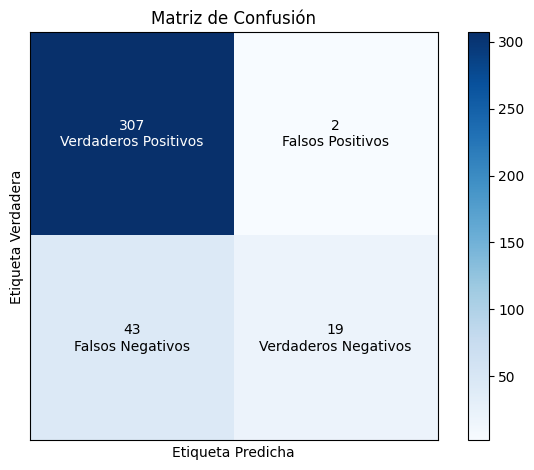

In [37]:
plot_matriz_conf(test_conf_matrix_sgdc_opt)

Llegado a este punto, es posible unir todos los resultados obtenidos para cada modelo y para cada set de datos, y hacer una comparación de sus métricas en conjunto.

In [38]:
dicc_metricas_SGDC = {
    'Modelo': ['SGDClassifier(Hiperparametros por Defecto)',
               'SGDClassifier(Hiperparametros por Defecto)',
               'SGDClassifier(Hiperparametros Optimizados)',
               'SGDClassifier(Hiperparametros Optimizador)'],
    'Set de Datos': ['Entrenamiento', 'Prueba', 'Entrenamiento', 'Prueba'],
    'Accuracy': [train_accu_sgdc, test_accu_sgdc, train_accu_sgdc_opt, test_accu_sgdc_opt],
    'Precision': [train_prec_sgdc, test_prec_sgdc, train_prec_sgdc_opt, test_prec_sgdc_opt ],
    'Recall': [train_recal_sgdc, test_recal_sgdc, train_recal_sgdc_opt, test_recal_sgdc_opt],
    'F1': [train_f1_sgdc, test_f1_sgdc, train_f1_sgdc_opt, test_f1_sgdc_opt]
}
df_metricas_SGDC = pd.DataFrame(dicc_metricas_SGDC)

In [39]:
df_metricas_SGDC

,Modelo,Set de Datos,Accuracy,Precision,Recall,F1
0,SGDClassifier(Hiperparametros por Defecto),Entrenamiento,0.850978,0.630000,0.255061,0.363112
1,SGDClassifier(Hiperparametros por Defecto),Prueba,0.854447,0.653846,0.274194,0.386364
2,SGDClassifier(Hiperparametros Optimizados),Entrenamiento,0.869858,0.800000,0.291498,0.427300
3,SGDClassifier(Hiperparametros Optimizador),Prueba,0.878706,0.904762,0.306452,0.457831


Es importante resaltar que la comparación de métricas sólo puede hacerse entre modelos evaluados en un mismo set de datos, es decir, se pueden comparar ambos modelos sobre datos de entrenamiento o cotejar ambos modelos evaluados sobre datos de prueba, pero no es posible comparar resultados de datos de entrenamiento con datos de prueba.

Es posible notar que el modelo 'SGDClassifier' con hiperparámetros optimizados tiene un mejor rendimiento que el modelo con hiperparametros por defecto, tanto en los datos de entrenamiento como en los datos de prueba.

Al comparar las matrices de confusión para analizar cómo son las predicciones de cada modelo, se obtuvo lo siguiente.

In [40]:
matr_conf_SGDC =[train_conf_matrix_sgdc,
            train_conf_matrix_sgdc_opt,
            test_conf_matrix_sgdc,
            test_conf_matrix_sgdc_opt]

titulos_SGDC = ['SGDC(Por Defecto)\nDatos de Entrenamientos',
               'SGDC(Optimizado)\nDatos de Entrenamientos',
               'SGDC(Por Defecto)\nDatos de Prueba',
               'SGDC(Optimizado)\nDatos de Prueba']

In [41]:
def plot_matrices_conf(matrices_confusion, titulos):
    interpretaciones = [['Verdaderos\nPositivos', 'Falsos\nPositivos'],
                       ['Falsos\nNegativos', 'Verdaderos\nNegativos']]

    # Crear el subplot de 2x2
    fig, axs = plt.subplots(2, 2, figsize=(10, 6))

    # Ubicar las matrices de confusión en el subplot
    for i in range(2):
        for j in range(2):
            matriz_confusion = matrices_confusion[i*2 + j]

            # Configurar el subplot
            ax = axs[i, j]
            im = ax.imshow(matriz_confusion, interpolation='nearest', cmap=plt.cm.Blues)
            ax.set(title=f'{titulos[i*2 + j]}')
            ax.set_xlabel('Etiqueta Predicha')
            ax.set_ylabel('Etiqueta Verdadera')
            ax.set_xticks([])
            ax.set_yticks([])

            # Añadir los valores y las interpretaciones en cada celda
            for k in range(matriz_confusion.shape[0]):
                for l in range(matriz_confusion.shape[1]):
                    ax.text(l, k, f'{matriz_confusion[k, l]}\n{interpretaciones[k][l]}',
                            ha="center", va="center", color="white" if matriz_confusion[k, l] > (matriz_confusion.max() / 2) else "black")


    # Ajustar el espaciado entre las gráficas
    plt.tight_layout()
    plt.show()


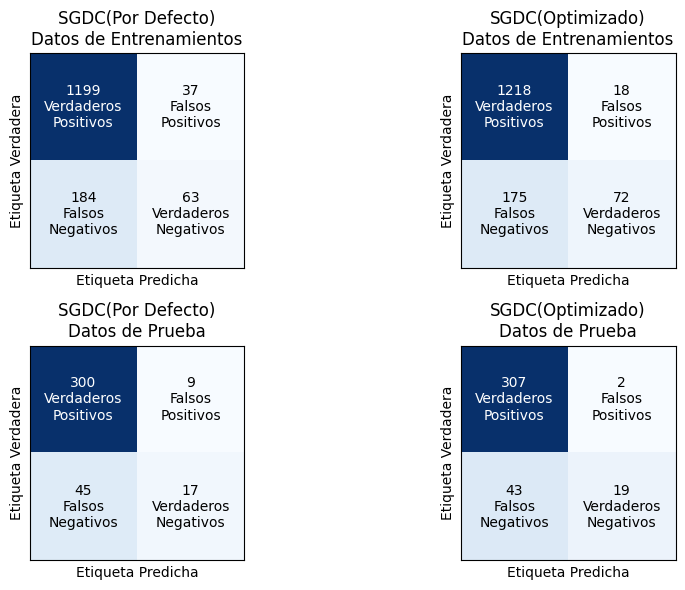

In [42]:
plot_matrices_conf(matr_conf_SGDC, titulos_SGDC)

En función a lo obtenido, es posible observar que hubo una mejora en la predicción de las etiquetas para el modelo con hiperparámetros optimizados: para datos de entrenamiento, la cantidad de etiquetas positivas (target = '1', es decir, gente que incumple el pago de sus prestamos) y negativas (target = '0', es decir, gente que paga sus prestamos) clasificadas correctamente, fue mayor para el modelo optimizado que para el modelo con hiperparámetros por defecto. Esto a su vez implicó una disminución de los valores falsamente clasificados. Este comportamiento también se repite en los datos de prueba, en los cuales es posible observar una mayor cantidad de etiquetas correctamente predichas por el modelo optimizado comparado con el modelo con parametros por defecto.

## Ejercicio 3: Árboles de Decisión

En este ejercicio se entrenarán árboles de decisión para predecir la variable objetivo.

Para ello, deberán utilizar la clase DecisionTreeClassifier de scikit-learn.

Documentación:
- https://scikit-learn.org/stable/modules/tree.html
  - https://scikit-learn.org/stable/modules/tree.html#tips-on-practical-use
- https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
- https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html

### Ejercicio 3.1: DecisionTreeClassifier con hiperparámetros por defecto

Entrenar y evaluar el clasificador DecisionTreeClassifier usando los valores por omisión de scikit-learn para todos los parámetros. Únicamente **fijar la semilla aleatoria** para hacer repetible el experimento.

Evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión


In [43]:
# Crear el modelo DecisionTreeClassifier con los valores por omisión
tree_model = DecisionTreeClassifier(random_state=0)

# Entrenar el modelo
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [44]:
# Realizar predicciones en el conjunto de entrenamiento y evaluación
y2_train_pred = tree_model.predict(X_train)
y2_test_pred = tree_model.predict(X_test)

In [45]:
# Calcular las métricas de evaluación en el conjunto de entrenamiento
train_accu_tree = accuracy_score(y_train, y2_train_pred)
train_prec_tree = precision_score(y_train, y2_train_pred)
train_recal_tree = recall_score(y_train, y2_train_pred)
train_f1_tree = f1_score(y_train, y2_train_pred)
train_conf_matrix_tree = confusion_matrix(y_train, y2_train_pred)

In [46]:
# Imprimir los resultados de las metricas del conjunto de entrenamiento
print("Resultados en el conjunto de entrenamiento:")
print("Accuracy:", train_accu_tree)
print("Precision:", train_prec_tree)
print("Recall:", train_recal_tree)
print("F1:", train_f1_tree)

Resultados en el conjunto de entrenamiento:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0


Las métricas perfectas que se observan para el conjunto de entrenamiento (Accuracy, Precision, Recall y F1 = 1.0) podrían estar indicando la presencia de overfitting en el modelo de Árbol de Decisión.

Cuando todas las métricas de evaluación del modelo tienen un valor de 1.0 en el conjunto de entrenamiento, esto sugiere que el modelo ha memorizado los ejemplos del conjunto de entrenamiento en lugar de aprender patrones generales que se apliquen a datos no vistos.

Es importante evaluar el rendimiento del modelo en un conjunto de datos independiente como el conjunto de prueba, el cual contiene ejemplos que el modelo no ha visto durante el entrenamiento. Si el modelo muestra un rendimiento significativamente inferior en el conjunto de prueba en comparación con el conjunto de entrenamiento, esto sería una confirmación adicional de que se ha producido overfitting.

Antes de continuar con el análisis de los resultados sobre el conjunto de prueba, se visualizó la matriz de confusión.

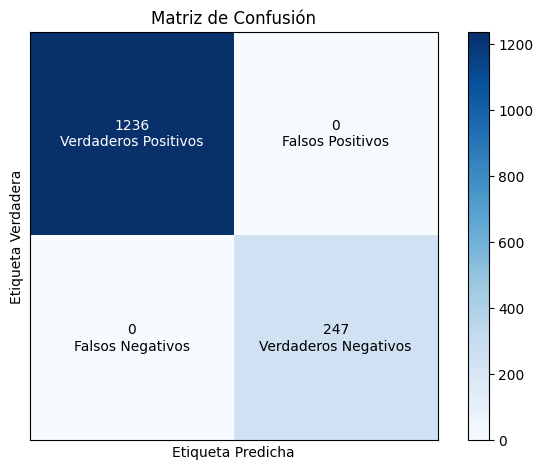

In [47]:
 plot_matriz_conf(train_conf_matrix_tree)

En base a lo obtenido, es posible observar que el modelo identificó correctamente todos los casos, tal como se vió reflejado en las metricas. En otras palabras, al haber sólo verdaderos positivos y negativos, el modelo clasificó correctamente todas las etiquetas.

Para poder comparar y corroborar que se estaba produciendo overfitting, se analizaron los resultados sobre el set de datos de prueba.

In [48]:
# Calcular las métricas de evaluación en el conjunto de prueba
test_accu_tree = accuracy_score(y_test, y2_test_pred)
test_prec_tree = precision_score(y_test, y2_test_pred)
test_recal_tree = recall_score(y_test, y2_test_pred)
test_f1_tree = f1_score(y_test, y2_test_pred)
test_conf_matrix_tree = confusion_matrix(y_test, y2_test_pred)

In [49]:
# Imprimir los resultados de las metricas del conjunto de prueba.
print("Resultados en el conjunto de prueba:")
print("Accuracy:", test_accu_tree)
print("Precision:", test_prec_tree)
print("Recall:", test_recal_tree)
print("F1:", test_f1_tree)

Resultados en el conjunto de prueba:
Accuracy: 0.8787061994609164
Precision: 0.660377358490566
Recall: 0.5645161290322581
F1: 0.6086956521739131


Comparando los resultados en el conjunto de prueba con los resultados anteriores en el conjunto de entrenamiento, se puede observar que las métricas son notablemente diferentes. Esto confirma que el modelo de Árbol de Decisión sufrió overfitting durante el entrenamiento.

En el conjunto de prueba, el *Accuracy* es de 0.8787, lo que indica que el modelo clasifica correctamente aproximadamente el 88% de los ejemplos del conjunto de prueba.

Además, la precisión en el conjunto de prueba es de 0.6604, lo que indica que alrededor del 66% de las predicciones positivas realizadas por el modelo son correctas. Esto es significativamente menor que la precisión perfecta de 1.0 obtenida en el conjunto de entrenamiento.

El *Recall* en el conjunto de prueba es de 0.5645, lo que significa que el modelo logra recuperar aproximadamente el 56% de los ejemplos positivos reales en el conjunto de prueba.

Estas diferencias entre las métricas del conjunto de entrenamiento y las del conjunto de prueba sugieren que el modelo de Árbol de Decisión no generaliza correctamente sobre datos no vistos y sobreajusta los ejemplos de entrenamiento, es decir, memoriza los ejemplos que vio durante el entrenamiento en lugar de aprender patrones generales que se apliquen a nuevos datos.

Analizando lo obtenido por la matriz de confusión:

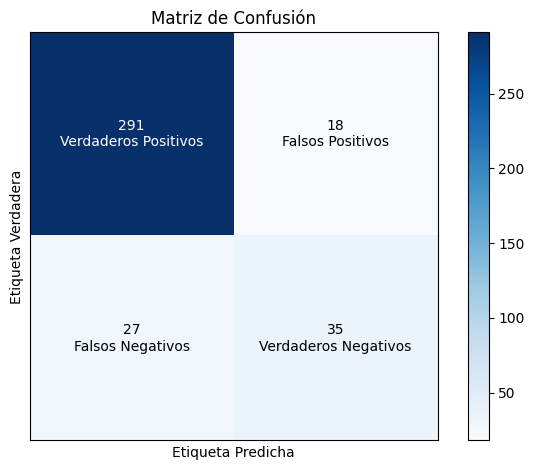

In [50]:
plot_matriz_conf(test_conf_matrix_tree)

Aquí es posible observar valores falsamente clasificados debido a la incapacidad del modelo de aprender patrones generales.

### Ejercicio 3.2: Ajuste de Hiperparámetros

Seleccionar valores para los hiperparámetros principales del DecisionTreeClassifier. Como mínimo, probar diferentes criterios de partición (criterion), profundidad máxima del árbol (max_depth), y cantidad mínima de samples por hoja (min_samples_leaf).

Para ello, usar grid-search y 5-fold cross-validation sobre el conjunto de entrenamiento para explorar muchas combinaciones posibles de valores.

Reportar accuracy promedio y varianza para todas las configuraciones.

Para la mejor configuración encontrada, evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión


Documentación:
- https://scikit-learn.org/stable/modules/grid_search.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

In [51]:
# Definir los hiperparámetros a explorar
tree_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7],
    'min_samples_leaf': [1, 2, 3]
}

In [52]:
# Crear el modelo DecisionTreeClassifier
tree_model_opt = DecisionTreeClassifier(random_state=0)

In [53]:
# Realizar grid-search con validación cruzada
grid_search = GridSearchCV(tree_model_opt, tree_param_grid, cv=5)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 3, 5, 7],
                         'min_samples_leaf': [1, 2, 3]})

In [54]:
# Obtener los resultados de grid-search
results = grid_search.cv_results_
best_params = grid_search.best_params_
best_score = grid_search.best_score_

In [55]:
print("\nMejor configuración encontrada:")
print("Best params:", best_params)
print("Best score (accuracy promedio):", best_score)


Mejor configuración encontrada:
Best params: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 3}
Best score (accuracy promedio): 0.8820024570024572


In [56]:
# Evaluar el modelo con la mejor configuración en el conjunto de entrenamiento y evaluación
best_model = grid_search.best_estimator_
y2_train_pred_opt = best_model.predict(X_train)
y2_test_pred_opt = best_model.predict(X_test)

In [57]:
# Calcular las métricas de evaluación en el conjunto de entrenamiento
train_accu_tree_opt = accuracy_score(y_train, y2_train_pred_opt)
train_prec_tree_opt = precision_score(y_train, y2_train_pred_opt)
train_recal_tree_opt = recall_score(y_train, y2_train_pred_opt)
train_f1_tree_opt = f1_score(y_train, y2_train_pred_opt)
train_conf_matrix_tree_opt = confusion_matrix(y_train, y2_train_pred_opt)

In [58]:
# Imprimir los resultados de las metricas del conjunto de entrenamiento.
print("Resultados en el conjunto de entrenamiento:")
print("Accuracy:", train_accu_tree_opt)
print("Precision:", train_prec_tree_opt)
print("Recall:", train_recal_tree_opt)
print("F1:", train_f1_tree_opt)

Resultados en el conjunto de entrenamiento:
Accuracy: 0.9224544841537424
Precision: 0.9285714285714286
Recall: 0.5789473684210527
F1: 0.7132169576059851


Un *Accuracy* de 0.9224 indica que el modelo clasifica correctamente alrededor del 92% de los ejemplos en el conjunto de entrenamiento. Este valor fue el mejor de todos los obtenidos hasta ahora (a excepcion del caso anterior donde se produjo overfitting).

Un *Precision* de 0.9286 significa que alrededor del 93% de las predicciones positivas realizadas por el modelo son correctas.

El *Recall* de 0.5789 indica que el modelo logra recuperar aproximadamente el 58% de los verdaderos positivos en el conjunto de entrenamiento.

Por último, un valor F1 de 0.7132 indica que el modelo tiene un rendimiento promedio de alrededor del 71% en la clasificación correcta de ejemplos positivos y negativos en el conjunto de entrenamiento.

Analizando la matriz de cofusión:

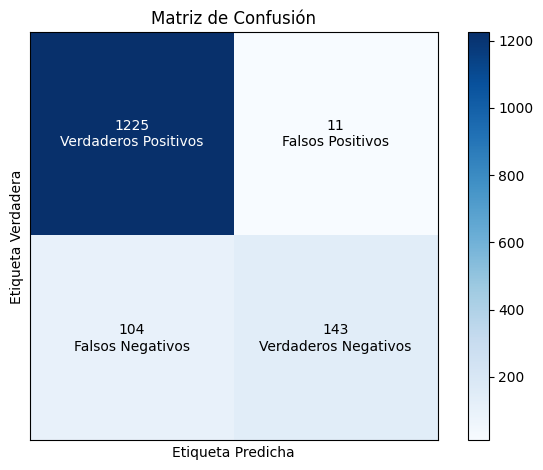

In [59]:
plot_matriz_conf(train_conf_matrix_tree_opt)

In [60]:
# Calcular las métricas de evaluación en el conjunto de prueba
test_accu_tree_opt = accuracy_score(y_test, y2_test_pred_opt)
test_prec_tree_opt = precision_score(y_test, y2_test_pred_opt)
test_recal_tree_opt = recall_score(y_test, y2_test_pred_opt)
test_f1_tree_opt = f1_score(y_test, y2_test_pred_opt)
test_conf_matrix_tree_opt = confusion_matrix(y_test, y2_test_pred_opt)

In [61]:
# Imprimir los resultados de las metricas del conjunto de prueba.
print("Resultados en el conjunto de prueba:")
print("Accuracy:", test_accu_tree_opt)
print("Precision:", test_prec_tree_opt)
print("Recall:", test_recal_tree_opt)
print("F1:", test_f1_tree_opt)

Resultados en el conjunto de prueba:
Accuracy: 0.894878706199461
Precision: 0.8285714285714286
Recall: 0.46774193548387094
F1: 0.5979381443298969


Un *Accuracy* de 0.8949 nos indica que el modelo clasifica correctamente aproximadamente el 89% de los ejemplos en el conjunto de prueba. Es ligeramente menor que el Accuracy en el conjunto de entrenamiento (0.9224). Esto indica que el modelo generaliza bien a nuevos datos, aunque con una ligera disminución en el rendimiento.

El Precision de 0.8286 significa que casi el 83% de las predicciones positivas realizadas son correctas en el conjunto de prueba. Este valor tambien es menor que la precisión en el conjunto de entrenamiento (0.9286), lo que sugiere que el modelo tiene una tasa más alta de falsos positivos en el conjunto de prueba en comparación con el conjunto de entrenamiento.

El Recall de 0.4677 nos dice que el modelo logra recuperar aproximadamente el 47% de los ejemplos positivos reales. Comparando con el valor obtenido en el conjunto de datos de entrenamiento, podemos decir que el modelo tiene dificultades para recuperar ejemplos positivos en el conjunto de prueba, lo cual es un indicio de un rendimiento deficiente en la detección de casos positivos.



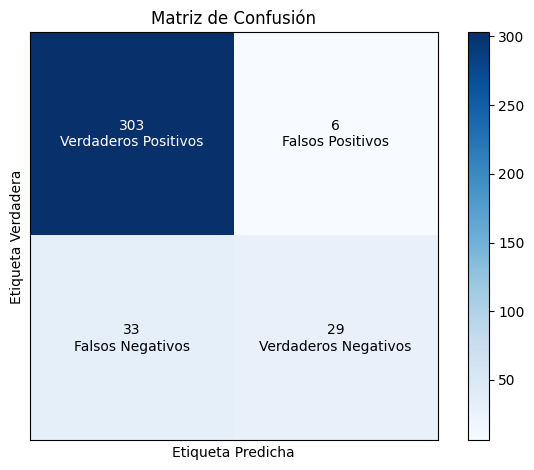

In [62]:
plot_matriz_conf(test_conf_matrix_tree_opt)

Nuevamente, se unieron todas las métricas obtenidas hasta el momento para analizarlas en conjunto y ver sus resultados.

In [63]:
dicc_metricas_TREE = {
    'Modelo': ['DTC (Hiperparametros por Defecto)',
               'DTC (Hiperparametros por Defecto)',
               'DTC (Hiperparametros Optimizados)',
               'DTC (Hiperparametros Optimizados)'],
    'Set de Datos': ['Entrenamiento', 'Prueba', 'Entrenamiento', 'Prueba'],
    'Accuracy': [train_accu_tree, test_accu_tree, train_accu_tree_opt, test_accu_tree_opt],
    'Precision': [train_prec_tree, test_prec_tree, train_prec_tree_opt, test_prec_tree_opt ],
    'Recall': [train_recal_tree, test_recal_tree, train_recal_tree_opt, test_recal_tree_opt],
    'F1': [train_f1_tree, test_f1_tree, train_f1_tree_opt, test_f1_tree_opt]
}
df_metricas_TREE = pd.DataFrame(dicc_metricas_TREE)

In [64]:
df_metricas_TREE

,Modelo,Set de Datos,Accuracy,Precision,Recall,F1
0,DTC (Hiperparametros por Defecto),Entrenamiento,1.000000,1.000000,1.000000,1.000000
1,DTC (Hiperparametros por Defecto),Prueba,0.878706,0.660377,0.564516,0.608696
2,DTC (Hiperparametros Optimizados),Entrenamiento,0.922454,0.928571,0.578947,0.713217
3,DTC (Hiperparametros Optimizados),Prueba,0.894879,0.828571,0.467742,0.597938


A partir del anterior cuadro, se peude decir que:

* En el modelo de Árbol de Decisión con hiperparámetros por defecto, existe un rendimiento inferior en el conjunto de prueba en comparación con el conjunto de entrenamiento (donde hubo overfitting). El accuracy, la precisión, el recall y el valor F1 son más bajos en el conjunto de prueba, lo que sugiere una falta de generalización y un rendimiento deficiente en la detección de casos positivos.

* Aunque el rendimiento en el conjunto de prueba es inferior al conjunto de entrenamiento en todos los modelos, hay una ligera mejora en el rendimiento del modelo con respecto al overfitting.

* Se puede deducir que los modelos de Árbol de Decisión con hiperparámetros por defecto presentan overfitting y no generalizan bien a nuevos datos. Es mas eficiente optimizar los hiperparámetros y usar técnicas de validación cruzada para mejorar el rendimiento y la capacidad de generalización del modelo. Además, es fundamental evaluar el rendimiento en conjuntos de prueba independientes para obtener una visión más precisa del rendimiento del modelo en datos no vistos.


A continuación, se compararon todas las matrices de confusión de los Árboles de Decisión.

In [65]:
matr_conf_TREE =[train_conf_matrix_tree,
            train_conf_matrix_tree_opt,
            test_conf_matrix_tree,
            test_conf_matrix_tree_opt]

titulos_TREE = ['DTC(Por Defecto)\nDatos de Entrenamientos',
               'DTC(Optimizado)\nDatos de Entrenamientos',
               'DTC(Por Defecto)\nDatos de Prueba',
               'DTC(Optimizado)\nDatos de Prueba']

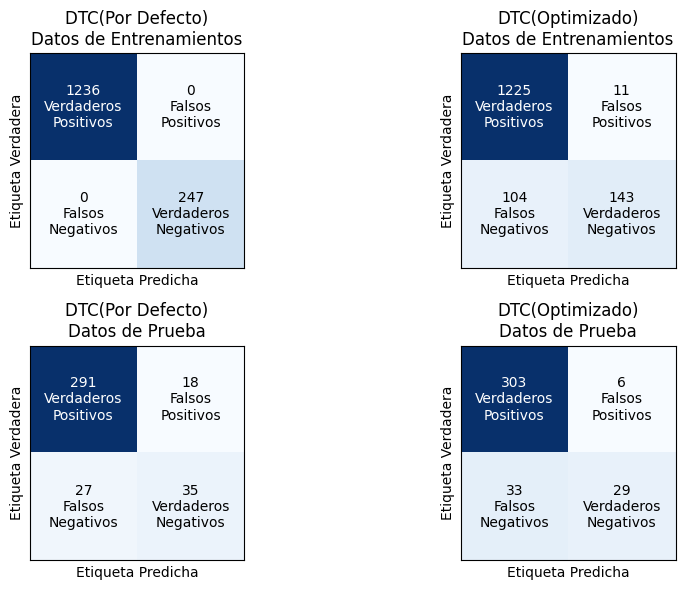

In [66]:
plot_matrices_conf(matr_conf_TREE, titulos_TREE)

Se compararon únicamente las matrices sobre los datos de prueba debido a que al tener un caso de overfitting, no se pudo hacer una comparación objetiva sobre los datos de entrenamiento. Es posible obervar que, efectivamente, al optimizar los hiperparámetros hubo una mejora en la clasificación de etiquetas. Además, hubo un aumento en la cantidad de casos verdaderamente clasificados y una disminución en los falsamente clasificados, lo que indica una mejora en el rendimiento del modelo.

Por último, se realizó una comparación entre todas las matrices de confusión para un último análisis de rendimiento de todos los modelos.

In [67]:
def plot_all_matrices_conf(matrices_confusion, titulos):
    interpretaciones = [['VP', 'FP'],
                       ['FN', 'VN']]

    # Crear el subplot de 2x2
    fig, axs = plt.subplots(2, 4, figsize=(12, 6))

    # Ubicar las matrices de confusión en el subplot
    for i in range(2):
        for j in range(4):
            matriz_confusion = matrices_confusion[i*4 + j]

            # Configurar el subplot
            ax = axs[i, j]
            im = ax.imshow(matriz_confusion, interpolation='nearest', cmap=plt.cm.Blues)
            ax.set(title=f'{titulos[i*4 + j]}')
            ax.set_xlabel('Etiqueta Predicha')
            ax.set_ylabel('Etiqueta Verdadera')
            ax.set_xticks([])
            ax.set_yticks([])

            # Añadir los valores y las interpretaciones en cada celda
            for k in range(matriz_confusion.shape[0]):
                for l in range(matriz_confusion.shape[1]):
                    ax.text(l, k, f'{matriz_confusion[k, l]}\n{interpretaciones[k][l]}',
                            ha="center", va="center", color="white" if matriz_confusion[k, l] > (matriz_confusion.max() / 2) else "black")


    # Ajustar el espaciado entre las gráficas
    plt.tight_layout()
    plt.show()

In [68]:
all_matr_conf =[train_conf_matrix_sgdc,
                train_conf_matrix_sgdc_opt,
                train_conf_matrix_tree,
                train_conf_matrix_tree_opt,
                test_conf_matrix_sgdc,
                test_conf_matrix_sgdc_opt,
                test_conf_matrix_tree,
                test_conf_matrix_tree_opt]

all_titulos = ['SGDC(Por Defecto)\nDatos de Entrenamientos',
                'SGDC(Optimizado)\nDatos de Entrenamientos',
                'DTC(Por Defecto)\nDatos de Entrenamientos',
                'DTC(Optimizado)\nDatos de Entrenamientos',
                'SGDC(Por Defecto)\nDatos de Prueba',
                'SGDC(Optimizado)\nDatos de Prueba',
                'DTC(Por Defecto)\nDatos de Prueba',
                'DTC(Optimizado)\nDatos de Prueba']

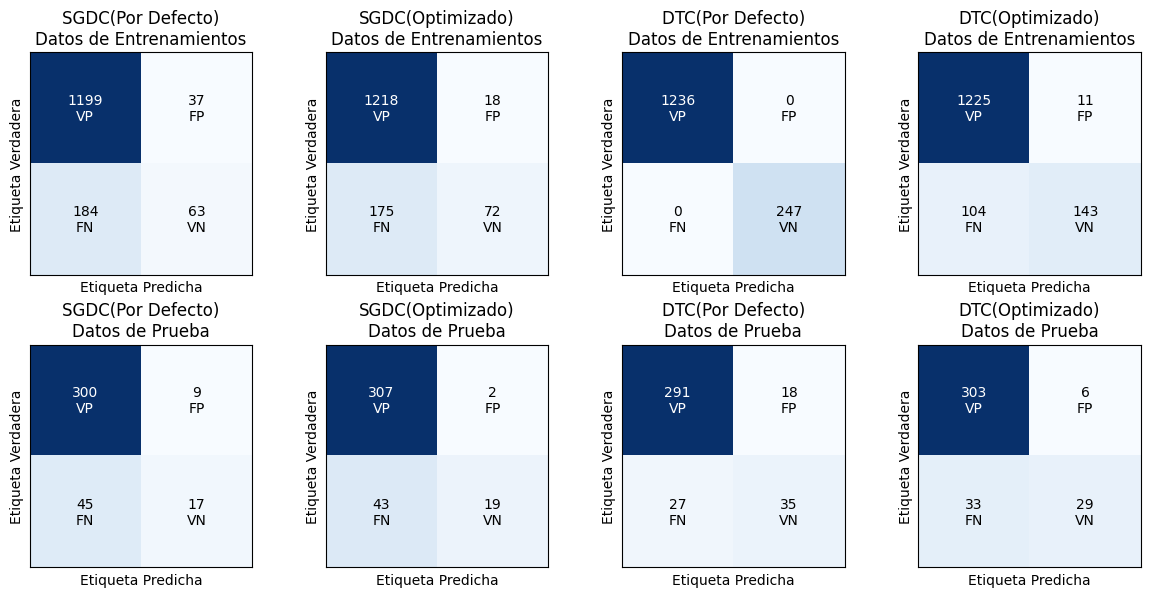

In [69]:
plot_all_matrices_conf(all_matr_conf, all_titulos)

A simple vista se puede decir que el rendimiento sobre el conjunto de datos de entranamiento es mejor para modelos optimizados (resultado esperable), y solo en este caso, el modelo de Árboles de Decisión parece mejor que el SGDClassifier, aún con hiperparámetros por defecto. En cambio, este último resultado pareciera no repetirse cuando se utilizan los conjuntos de prueba. Aunque se repite el hecho de que trabajar con modelo de hiperparámetros optimizados da mejores resultados, el SGDClassifier parece tener un mejor rendimiento por sobre el modelo basado en Árboles de Decisión.